In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots


### Load dataset

In [2]:
cls=pd.read_csv("../data/classroom.csv")

In [3]:
cls.head()

,CID,Occupancy,10:00-12:00,12:00-02:00,02:30-04:30,04:30-05:30
0,C001,20,AI-A10,MERN-A10,MERN-A09,MERN-B10
1,C002,20,BA-A10,PHP-A10,PHP-A09,PHP-B10
2,C003,20,DS-A10,Python-A10,Python-A09,Python-B10
3,C004,20,DevOps-A10,React-A10,React-A09,React-B10
4,C005,20,Flutter-A10,UIUX-A10,UIUX-A09,UIUX-B10


In [4]:
cls.columns

Index(['CID', 'Occupancy', '10:00-12:00', '12:00-02:00', '02:30-04:30',
       '04:30-05:30'],
      dtype='object')

In [5]:
cls.duplicated().sum()

np.int64(0)

In [6]:
cls.isna().sum()

CID            0
Occupancy      0
10:00-12:00    0
12:00-02:00    0
02:30-04:30    0
04:30-05:30    0
dtype: int64

## Classroom

### KPI's

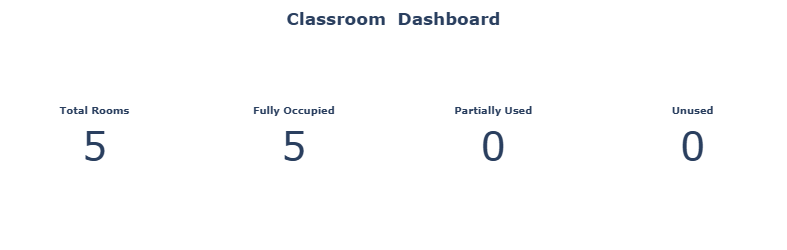

In [7]:

# --- Data ---
time_slots = ['10:00-12:00', '12:00-02:00', '02:30-04:30', '04:30-05:30']

def slot_filled(row):
    return sum(1 for s in time_slots if str(row.get(s, '')).strip() not in ['', 'nan', 'None'])

cls['filled_slots'] = cls.apply(slot_filled, axis=1)

total_rooms     = len(cls)
max_slots       = len(time_slots)

fully_occupied  = int((cls['filled_slots'] == max_slots).sum())
partially_used  = int(((cls['filled_slots'] > 0) & (cls['filled_slots'] < max_slots)).sum())
unused          = int((cls['filled_slots'] == 0).sum())

# --- Figure ---
fig = go.Figure()

def add_kpi(value, title, x_pos):
    fig.add_trace(go.Indicator(
        mode="number",
        value=value,
        title={"text": f"<b>{title}</b>"},
        number={"font": {"size": 40}},
        domain={'x': x_pos, 'y': [0, 1]}
    ))

# --- Add KPIs ---
add_kpi(total_rooms,    "Total Rooms",      [0.00, 0.22])
add_kpi(fully_occupied, "Fully Occupied",   [0.26, 0.48])
add_kpi(partially_used, "Partially Used",   [0.52, 0.74])
add_kpi(unused,         "Unused",           [0.78, 1.00])

# --- Layout ---
fig.update_layout(
    title="<b>Classroom  Dashboard</b>",
    title_x=0.5,
    height=250,
    margin=dict(t=50, b=10, l=10, r=10)
)

fig.show()

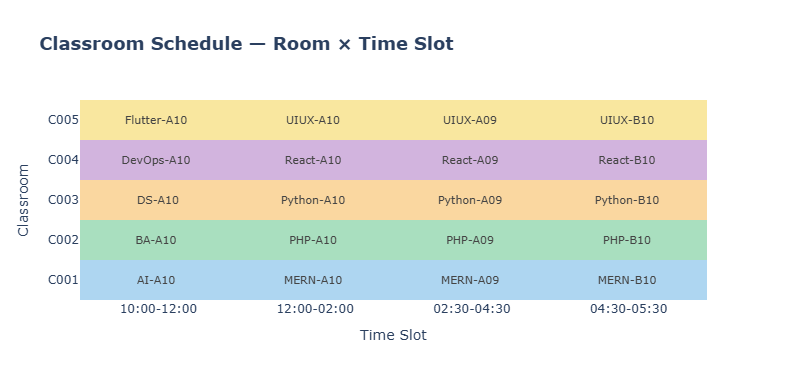

In [8]:
time_slots = ['10:00-12:00','12:00-02:00','02:30-04:30','04:30-05:30']

z_text = []
for _, row in cls.iterrows():
    z_text.append([str(row[s]) for s in time_slots])

# numeric dummy for colour (just slot index)
z_val = [[i+1]*len(time_slots) for i in range(len(cls))]

fig = go.Figure(go.Heatmap(
    z=z_val,
    x=time_slots,
    y=cls['CID'].tolist(),
    text=z_text,
    texttemplate='%{text}',
    textfont_size=11,
    colorscale=[
        [0.0,  '#AED6F1'],
        [0.25, '#A9DFBF'],
        [0.5,  '#FAD7A0'],
        [0.75, '#D2B4DE'],
        [1.0,  '#F9E79F'],
    ],
    showscale=False,
    hovertemplate='<b>%{y} — %{x}</b><br>%{text}<extra></extra>'
))

fig.update_layout(
    title_text='<b>Classroom Schedule — Room × Time Slot</b>',
    title_font_size=18,
    xaxis_title='Time Slot',
    yaxis_title='Classroom',
    height=380,
    paper_bgcolor='white'
)
fig.show()